#📈 NYSE Stock Price Prediction with LSTM
In this notebook, we use a simple LSTM model to predict the next closing price of a stock.

We use the previous 60 trading days as input.

Input features:

>Open

>High

>Low

>Close

>Volume

Target:
Next day's Close price

Dataset:
https://www.kaggle.com/datasets/dgawlik/nyse

# **Mount Drive**

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Extract Dataset**

In [23]:
import zipfile, os

DATA_PATH = '/content/drive/MyDrive/New York Stock Exchange/archive (1).zip'
extract_path = '/content/nyse_data'

with zipfile.ZipFile(DATA_PATH, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir(extract_path))

['fundamentals.csv', 'securities.csv', 'prices-split-adjusted.csv', 'prices.csv']


# **Import Libraries**

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

# **Load Dataset**

In [25]:
df = pd.read_csv('/content/nyse_data/prices-split-adjusted.csv')

SYMBOL = 'AAPL'

stock_df = df[df['symbol'] == SYMBOL].copy()

stock_df['date'] = pd.to_datetime(stock_df['date'])

stock_df = stock_df.sort_values('date').reset_index(drop=True)

stock_df.dropna(inplace=True)

# **Select Features**

In [26]:
features = ['open', 'high', 'low', 'close', 'volume']

stock_df = stock_df[['date'] + features]

print("Dataset shape:", stock_df.shape)

print(stock_df.head())

Dataset shape: (1762, 6)
        date       open       high        low      close       volume
0 2010-01-04  30.490000  30.642857  30.340000  30.572857  123432400.0
1 2010-01-05  30.657143  30.798571  30.464285  30.625713  150476200.0
2 2010-01-06  30.625713  30.747143  30.107143  30.138571  138040000.0
3 2010-01-07  30.250000  30.285715  29.864286  30.082857  119282800.0
4 2010-01-08  30.042856  30.285715  29.865715  30.282858  111902700.0


# **prepare Data**

In [27]:
data = stock_df[features].values

print("Input features:", features)
print("Data shape:", data.shape)

Input features: ['open', 'high', 'low', 'close', 'volume']
Data shape: (1762, 5)


# **Train/Val/Test**

In [28]:
train_end = int(len(data) * 0.70)
val_end = int(len(data) * 0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]


print("Train data:", train_data.shape)
print("Validation data:", val_data.shape)
print("Test data:", test_data.shape)

Train data: (1233, 5)
Validation data: (264, 5)
Test data: (265, 5)


# **Scale Data**

In [29]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)

val_scaled = scaler.transform(val_data)

test_scaled = scaler.transform(test_data)

# **Creaate Sequence**

In [33]:
WINDOW_SIZE = 60


def create_sequences(data, window_size):
    X = []
    y = []

    for i in range(window_size, len(data)):

        X.append(data[i-window_size:i])
        y.append(data[i, 3])
    return np.array(X), np.array(y)



X_train, y_train = create_sequences(train_scaled, WINDOW_SIZE)
val_input = np.concatenate(
    [train_scaled[-WINDOW_SIZE:], val_scaled]
    )

X_val, y_val = create_sequences(val_input, WINDOW_SIZE)

test_input = np.concatenate([val_scaled[-WINDOW_SIZE:], test_scaled])

X_test, y_test = create_sequences(test_input, WINDOW_SIZE)


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1173, 60, 5)
y_train: (1173,)
X_val: (264, 60, 5)
y_val: (264,)
X_test: (265, 60, 5)
y_test: (265,)


# **Build LSTM Model**

In [34]:
model = Sequential()

model.add(LSTM(128, input_shape=(X_train.shape[1], X_train.shape[2])))

model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **Compile Model**

In [35]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['mae']
)


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 128)            │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,737 (268.50 KB)

 Trainable params: 68,737 (268.50 KB)

 Non-trainable params: 0 (0.00 B)

# **callbacks**

In [36]:
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# **Model training**

In [37]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0251 - mae: 0.1005 - val_loss: 0.0062 - val_mae: 0.0711 - learning_rate: 0.0010
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0024 - mae: 0.0358 - val_loss: 0.0027 - val_mae: 0.0444 - learning_rate: 0.0010
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021 - mae: 0.0334 - val_loss: 0.0019 - val_mae: 0.0363 - learning_rate: 0.0010
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0017 - mae: 0.0304 - val_loss: 0.0023 - val_mae: 0.0409 - learning_rate: 0.0010
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0016 - mae: 0.0301 - val_loss: 0.0011 - val_mae: 0.0263 - learning_rate: 0.0010
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0015 - mae: 0.0288 - val_loss: 0.0015 - val_mae: 0.0321 - learning_rate: 0.0010
Epoch 7/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0015 - mae: 0.0287 - val_loss: 0.0012 - val_mae: 0.0269 - learning_rate: 0.0010
Epoch 8/150


# **Plot Training Loss**

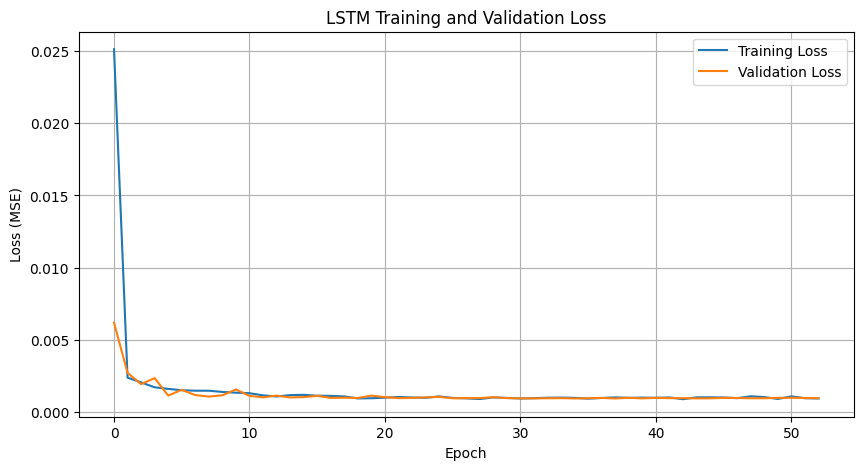

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# **Predict**

In [39]:
y_pred_scaled = model.predict(X_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


# **Inverse Transform**

In [40]:
dummy_pred = np.zeros(
    (len(y_pred_scaled), len(features))
)

dummy_pred[:, 3] = y_pred_scaled[:, 0]

y_pred = scaler.inverse_transform(dummy_pred)[:, 3]


dummy_test = np.zeros((len(y_test), len(features)))
dummy_test[:, 3] = y_test

y_test_actual = scaler.inverse_transform(dummy_test)[:, 3]

# **Evaleuation**

In [41]:
mse = mean_squared_error(y_test_actual, y_pred)
mae = mean_absolute_error(y_test_actual, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual,y_pred)


print("===== LSTM Results =====")
print(f"MSE:  {mse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

===== LSTM Results =====
MSE:  5.8299
MAE:  1.8507
RMSE: 2.4145
R²:   0.8962


# **Actual vs Predicted chart**

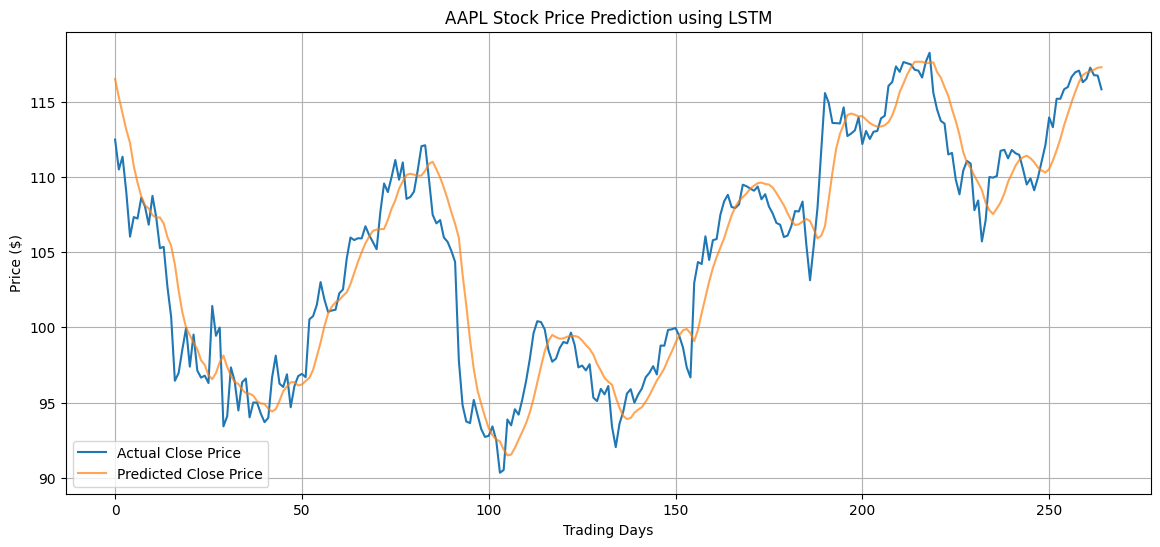

In [42]:
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual,label='Actual Close Price')
plt.plot(y_pred, label='Predicted Close Price', alpha=0.7)
plt.title(f'{SYMBOL} Stock Price Prediction using LSTM')
plt.xlabel('Trading Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()